### This notebook builds the preprocessing pipeline for our loaded datasets

In [1]:
#Importing required libraries
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from pathlib import Path

In [2]:
#Loading the datasets
mrpc = load_dataset("glue","mrpc")
qqp = load_dataset("glue","qqp")
paws = load_dataset("paws","labeled_final")
mscoco = load_dataset("sentence-transformers/coco-captions")

datasets = {
    "MRPC": mrpc,
    "QQP": qqp,
    "PAWS": paws,
    "MSCOCO": mscoco
}

In [3]:
#Dataset Statistics
summary = []

for name, ds in datasets.items():
    for split in ds.keys():
        summary.append({
            "Dataset": name,
            "Split": split,
            "Samples": len(ds[split]),
            "Columns": ", ".join(ds[split].column_names)
        })

summary_df = pd.DataFrame(summary)
summary_df

,Dataset,Split,Samples,Columns
0,MRPC,train,3668,"sentence1, sentence2, label, idx"
1,MRPC,validation,408,"sentence1, sentence2, label, idx"
2,MRPC,test,1725,"sentence1, sentence2, label, idx"
3,QQP,train,363846,"question1, question2, label, idx"
4,QQP,validation,40430,"question1, question2, label, idx"
5,QQP,test,390965,"question1, question2, label, idx"
6,PAWS,train,49401,"id, sentence1, sentence2, label"
7,PAWS,test,8000,"id, sentence1, sentence2, label"
8,PAWS,validation,8000,"id, sentence1, sentence2, label"
9,MSCOCO,train,414010,"caption1, caption2"


In [4]:
#Saving the results
summary_df.to_csv(
    "../results/metrics/dataset_statistics.csv",
    index=False
)

In [6]:
#Sentence Length Analysis
def sentence_lengths(dataset,column):
    lengths = [
        len(str(x).split())
        for x in dataset[column]
    ]
    return lengths

In [7]:
#Vocabulary Analysis
def vocabulary(dataset,column):
    words=[]
    for sentence in dataset[column]:
        words.extend(
            str(sentence).lower().split()
        )
    return Counter(words)

In [8]:
#Lexical Similarity
def jaccard(s1,s2):
    a=set(s1.lower().split())
    b=set(s2.lower().split())
    return len(a&b)/len(a|b)

In [9]:
#Data Quality
def check_quality(dataset,column):
    print("Nulls")
    print(
        pd.Series(dataset[column]).isnull().sum()
    )
    print()
    print("Duplicates")
    print(
        pd.Series(dataset[column]).duplicated().sum()
    )

# 1. MRPC

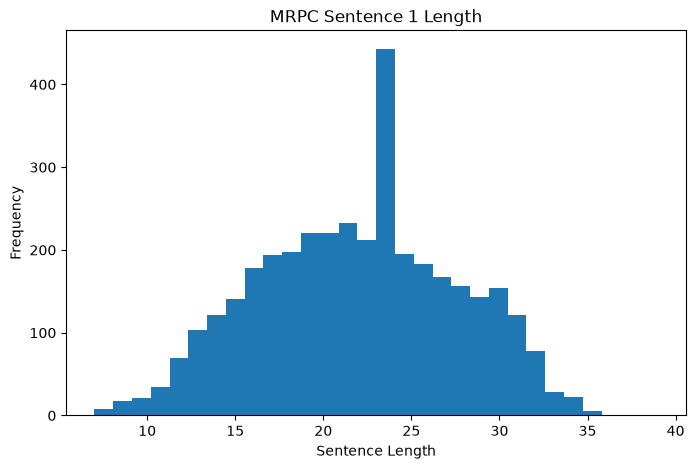

Mean: 21.942748091603054
Median: 22.0
Max: 39
Min: 7


In [12]:
#Sentence Length Analysis
lengths = sentence_lengths(
    mrpc["train"],
    "sentence1"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("MRPC Sentence 1 Length")
plt.savefig("../results/plots/mrpc_sentence1_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

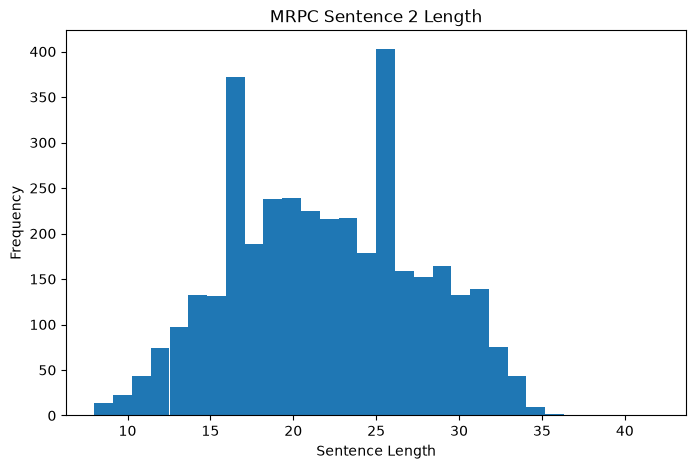

Mean: 21.946564885496183
Median: 22.0
Max: 42
Min: 8


In [13]:
lengths = sentence_lengths(
    mrpc["train"],
    "sentence2"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("MRPC Sentence 2 Length")
plt.savefig("../results/plots/mrpc_sentence2_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

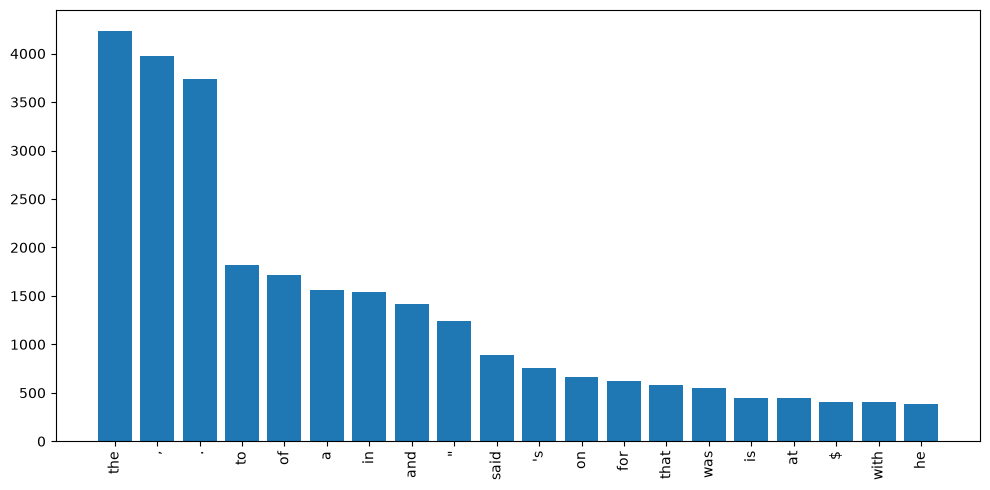

In [14]:
#Vocabulary Analysis
counter = vocabulary(
    mrpc["train"],
    "sentence1"
)
counter.most_common(20)
top = counter.most_common(20)

words = [x[0] for x in top]
freq = [x[1] for x in top]
plt.figure(figsize=(10,5))
plt.bar(words,freq)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/plots/mrpc_top_words.png")
plt.show()

In [15]:
#Lexical Similarity
scores=[]

for row in mrpc["train"]:
    scores.append(
        jaccard(
            row["sentence1"],
            row["sentence2"]
        )
    )
print(np.mean(scores))

0.5349643158544428


In [16]:
#Data Quality
check_quality(
    mrpc["train"],
    "sentence1"
)

Nulls
0

Duplicates
0


In [17]:
check_quality(
    mrpc["train"],
    "sentence2"
)

Nulls
0

Duplicates
146


# 2.QQP

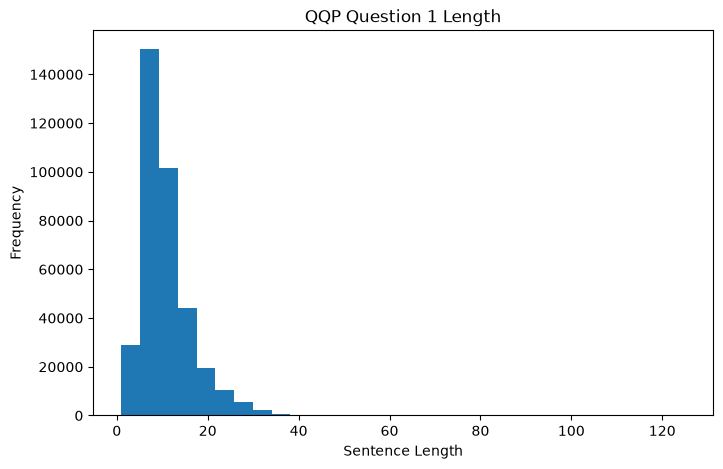

Mean: 10.94282196313825
Median: 10.0
Max: 125
Min: 1


In [19]:
#Sentence Length Analysis
lengths = sentence_lengths(
    qqp["train"],
    "question1"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("QQP Question 1 Length")
plt.savefig("../results/plots/qqp_question1_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

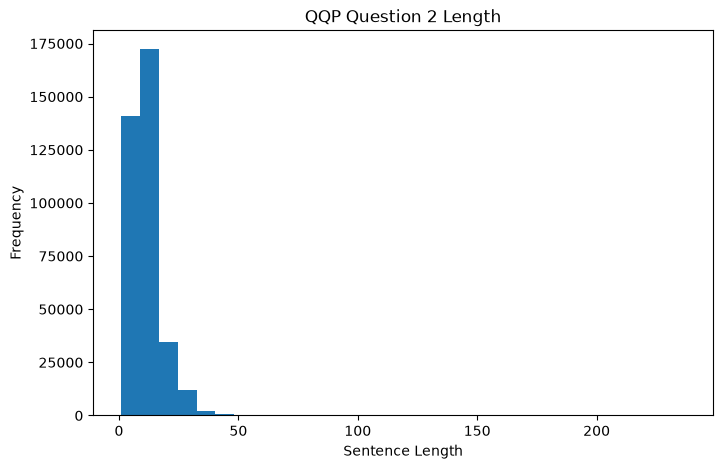

Mean: 11.183467730853163
Median: 10.0
Max: 237
Min: 1


In [20]:
lengths = sentence_lengths(
    qqp["train"],
    "question2"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("QQP Question 2 Length")
plt.savefig("../results/plots/qqp_question2_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

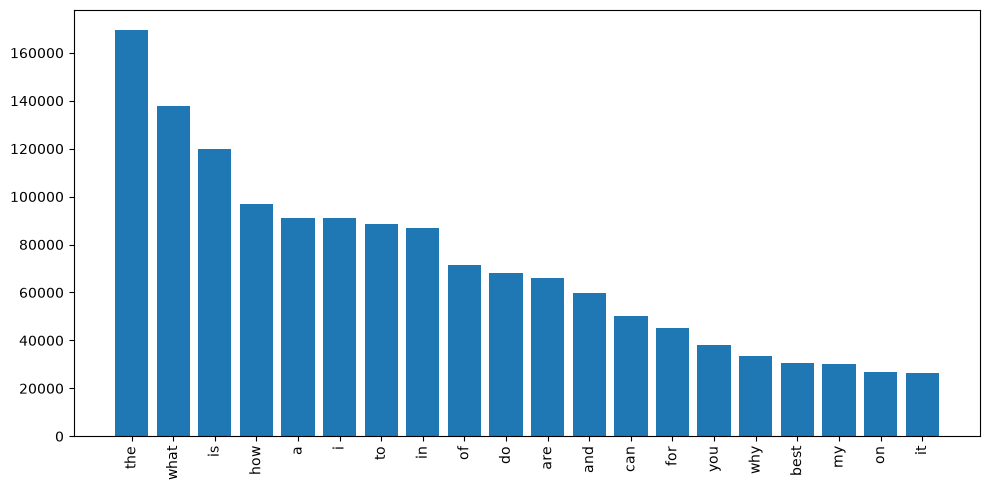

In [21]:
#Vocabulary Analysis
counter = vocabulary(
    qqp["train"],
    "question1"
)
counter.most_common(20)
top = counter.most_common(20)

words = [x[0] for x in top]
freq = [x[1] for x in top]
plt.figure(figsize=(10,5))
plt.bar(words,freq)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/plots/qqp_top_words.png")
plt.show()

In [22]:
#Lexical Similarity
scores=[]

for row in qqp["train"]:
    scores.append(
        jaccard(
            row["question1"],
            row["question2"]
        )
    )
print(np.mean(scores))

0.32442050295874986


In [23]:
#Data Quality
check_quality(
    qqp["train"],
    "question1"
)

Nulls
0

Duplicates
97521


In [24]:
#Data Quality
check_quality(
    qqp["train"],
    "question2"
)

Nulls
0

Duplicates
90453


# 3. PAWS

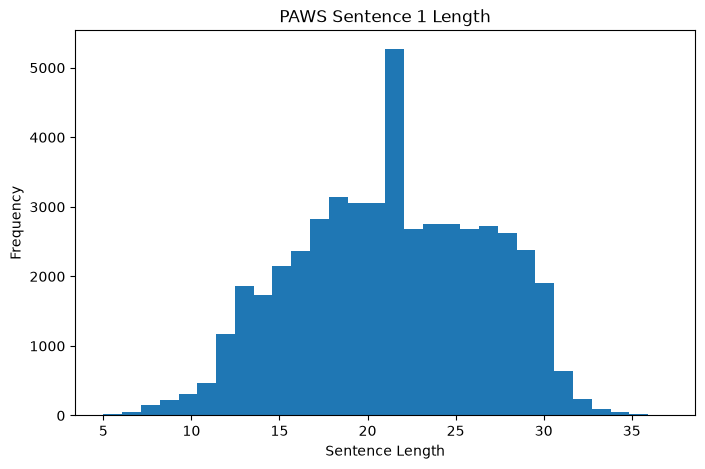

Mean: 21.340782575251513
Median: 21.0
Max: 37
Min: 5


In [25]:
#Sentence Length Analysis
lengths = sentence_lengths(
    paws["train"],
    "sentence1"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("PAWS Sentence 1 Length")
plt.savefig("../results/plots/paws_sentence1_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

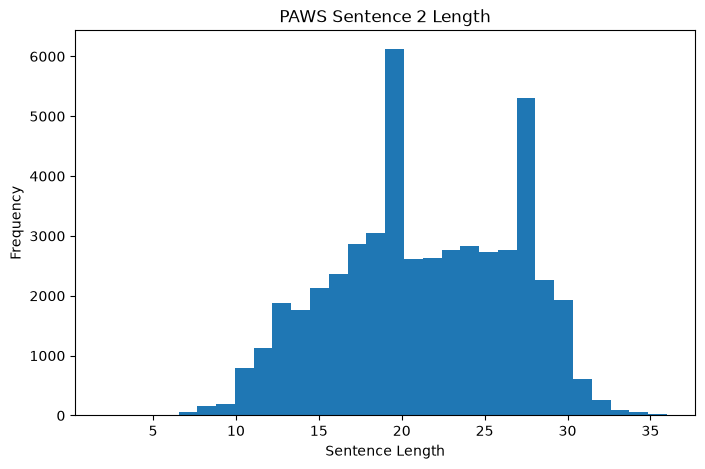

Mean: 21.337948624521772
Median: 21.0
Max: 36
Min: 2


In [26]:
#Sentence Length Analysis
lengths = sentence_lengths(
    paws["train"],
    "sentence2"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("PAWS Sentence 2 Length")
plt.savefig("../results/plots/paws_sentence2_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

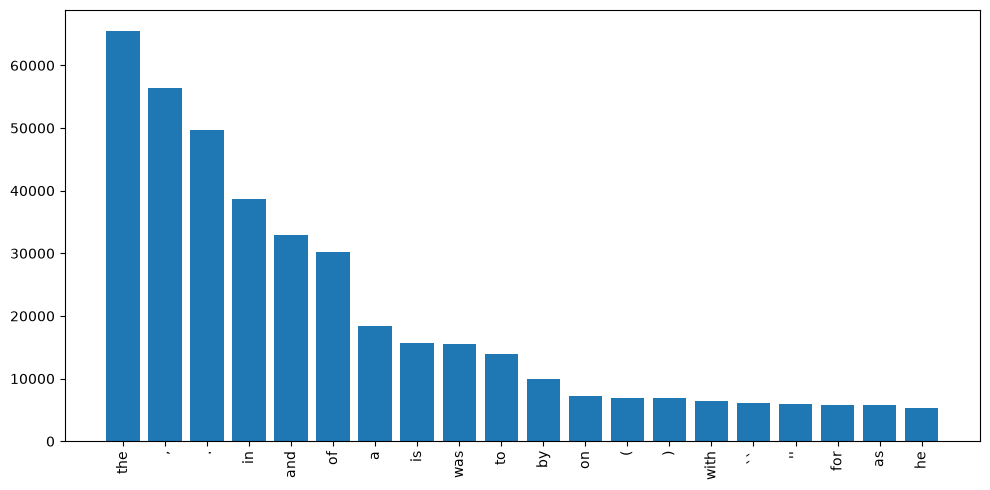

In [27]:
#Vocabulary Analysis
counter = vocabulary(
    paws["train"],
    "sentence1"
)
counter.most_common(20)
top = counter.most_common(20)

words = [x[0] for x in top]
freq = [x[1] for x in top]
plt.figure(figsize=(10,5))
plt.bar(words,freq)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/plots/paws_top_words.png")
plt.show()

In [28]:
#Lexical Similarity
scores=[]

for row in paws["train"]:
    scores.append(
        jaccard(
            row["sentence1"],
            row["sentence2"]
        )
    )
print(np.mean(scores))

0.8848337079946046


In [29]:
#Data Quality
check_quality(
    paws["train"],
    "sentence1"
)

Nulls
0

Duplicates
18726


In [30]:
#Data Quality
check_quality(
    paws["train"],
    "sentence1"
)

Nulls
0

Duplicates
18726


# MSCOCO Captions

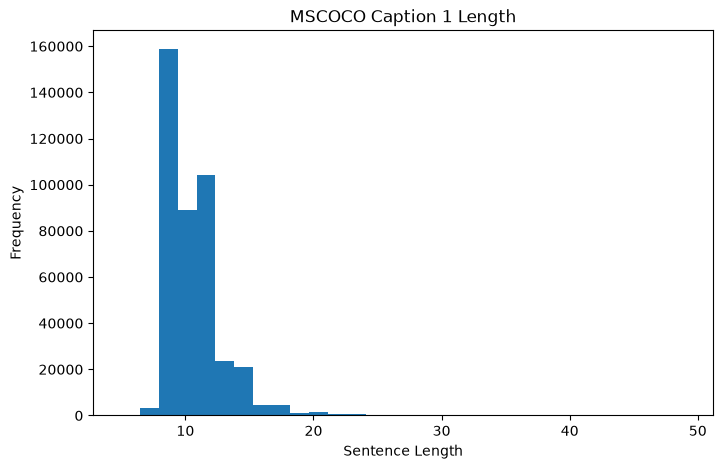

Mean: 10.458621772420956
Median: 10.0
Max: 49
Min: 5


In [31]:
#Sentence Length Analysis
lengths = sentence_lengths(
    mscoco["train"],
    "caption1"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("MSCOCO Caption 1 Length")
plt.savefig("../results/plots/mscoco_caption1_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

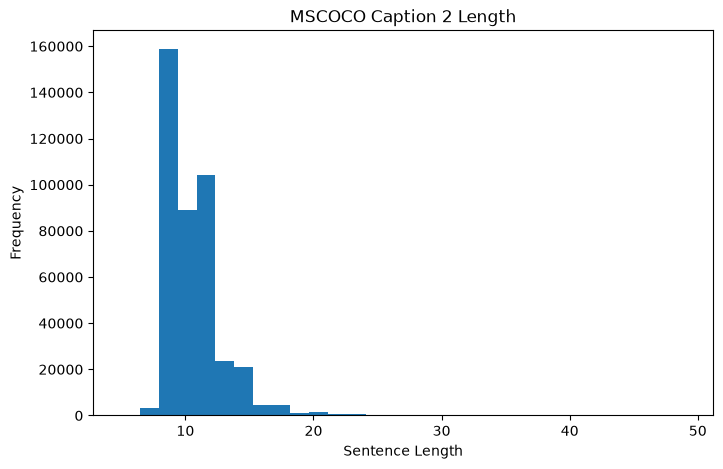

Mean: 10.458621772420956
Median: 10.0
Max: 49
Min: 5


In [32]:
#Sentence Length Analysis
lengths = sentence_lengths(
    mscoco["train"],
    "caption2"
)

plt.figure(figsize=(8,5))
plt.hist(lengths,bins=30)
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("MSCOCO Caption 2 Length")
plt.savefig("../results/plots/mscoco_caption2_lengths.png")
plt.show()

print("Mean:",np.mean(lengths))
print("Median:",np.median(lengths))
print("Max:",np.max(lengths))
print("Min:",np.min(lengths))

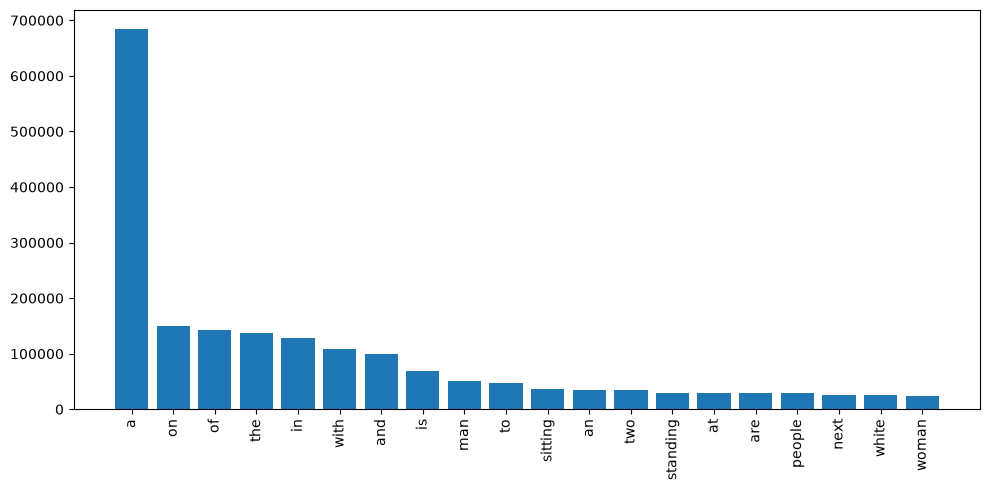

In [33]:
#Vocabulary Analysis
counter = vocabulary(
    mscoco["train"],
    "caption1"
)
counter.most_common(20)
top = counter.most_common(20)

words = [x[0] for x in top]
freq = [x[1] for x in top]
plt.figure(figsize=(10,5))
plt.bar(words,freq)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../results/plots/mscoco_top_words.png")
plt.show()

In [34]:
#Lexical Similarity
scores=[]

for row in mscoco["train"]:
    scores.append(
        jaccard(
            row["caption1"],
            row["caption2"]
        )
    )
print(np.mean(scores))

0.21035622672915083


In [35]:
#Data Quality
check_quality(
    mscoco["train"],
    "caption1"
)

Nulls
0

Duplicates
13048


In [36]:
#Data Quality
check_quality(
    mscoco["train"],
    "caption2"
)

Nulls
0

Duplicates
13048


In [37]:
#Convert Hugging Face Dataset to DataFrame
mrpc_train = mrpc["train"].to_pandas()
mrpc_validation = mrpc["validation"].to_pandas()
mrpc_test = mrpc["test"].to_pandas()

qqp_train = qqp["train"].to_pandas()
qqp_validation = qqp["validation"].to_pandas()
qqp_test = qqp["test"].to_pandas()

paws_train = paws["train"].to_pandas()
paws_validation = paws["validation"].to_pandas()
paws_test = paws["test"].to_pandas()

In [38]:
#Preprocessing
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import (
    preprocess_classical,
    preprocess_transformer
)

In [39]:
#Classical ML Datasets
mrpc_train_classical = preprocess_classical(
    mrpc_train.copy(),
    "sentence1",
    "sentence2"
)

mrpc_validation_classical = preprocess_classical(
    mrpc_validation.copy(),
    "sentence1",
    "sentence2"
)

mrpc_test_classical = preprocess_classical(
    mrpc_test.copy(),
    "sentence1",
    "sentence2"
)

In [40]:
qqp_train_classical = preprocess_classical(
    qqp_train.copy(),
    "question1",
    "question2"
)

qqp_validation_classical = preprocess_classical(
    qqp_validation.copy(),
    "question1",
    "question2"
)

qqp_test_classical = preprocess_classical(
    qqp_test.copy(),
    "question1",
    "question2"
)

In [41]:
#Classical ML Datasets
paws_train_classical = preprocess_classical(
    paws_train.copy(),
    "sentence1",
    "sentence2"
)

paws_validation_classical = preprocess_classical(
    paws_validation.copy(),
    "sentence1",
    "sentence2"
)

paws_test_classical = preprocess_classical(
    paws_test.copy(),
    "sentence1",
    "sentence2"
)

In [42]:
#Create Transformer Datasets
mrpc_train_transformer = preprocess_transformer(
    mrpc_train.copy(),
    "sentence1",
    "sentence2"
)

mrpc_validation_transformer = preprocess_transformer(
    mrpc_validation.copy(),
    "sentence1",
    "sentence2"
)

mrpc_test_transformer = preprocess_transformer(
    mrpc_test.copy(),
    "sentence1",
    "sentence2"
)

In [43]:
qqp_train_transformer = preprocess_transformer(
    qqp_train.copy(),
    "question1",
    "question2"
)

qqp_validation_transformer = preprocess_transformer(
    qqp_validation.copy(),
    "question1",
    "question2"
)

qqp_test_transformer = preprocess_transformer(
    qqp_test.copy(),
    "question1",
    "question2"
)

In [44]:
paws_train_transformer = preprocess_transformer(
    paws_train.copy(),
    "sentence1",
    "sentence2"
)

paws_validation_transformer = preprocess_transformer(
    paws_validation.copy(),
    "sentence1",
    "sentence2"
)

paws_test_transformer = preprocess_transformer(
    paws_test.copy(),
    "sentence1",
    "sentence2"
)

In [45]:
#Save Classical Datasets
mrpc_train_classical.to_csv(
    "../datasets/processed/classical/mrpc_train.csv",
    index=False
)

mrpc_validation_classical.to_csv(
    "../datasets/processed/classical/mrpc_validation.csv",
    index=False
)

mrpc_test_classical.to_csv(
    "../datasets/processed/classical/mrpc_test.csv",
    index=False
)

In [46]:
qqp_train_classical.to_csv(
    "../datasets/processed/classical/qqp_train.csv",
    index=False
)

qqp_validation_classical.to_csv(
    "../datasets/processed/classical/qqp_validation.csv",
    index=False
)

qqp_test_classical.to_csv(
    "../datasets/processed/classical/qqp_test.csv",
    index=False
)

In [47]:
paws_train_classical.to_csv(
    "../datasets/processed/classical/paws_train.csv",
    index=False
)

paws_validation_classical.to_csv(
    "../datasets/processed/classical/paws_validation.csv",
    index=False
)

paws_test_classical.to_csv(
    "../datasets/processed/classical/paws_test.csv",
    index=False
)

In [48]:
#Save Transformer Datasets
mrpc_train_transformer.to_csv(
    "../datasets/processed/transformer/mrpc_train.csv",
    index=False
)

mrpc_validation_transformer.to_csv(
    "../datasets/processed/transformer/mrpc_validation.csv",
    index=False
)

mrpc_test_transformer.to_csv(
    "../datasets/processed/transformer/mrpc_test.csv",
    index=False
)

In [49]:
qqp_train_classical.to_csv(
    "../datasets/processed/transformer/qqp_train.csv",
    index=False
)

qqp_validation_classical.to_csv(
    "../datasets/processed/transformer/qqp_validation.csv",
    index=False
)

qqp_test_classical.to_csv(
    "../datasets/processed/transformer/qqp_test.csv",
    index=False
)

In [50]:
paws_train_classical.to_csv(
    "../datasets/processed/transformer/paws_train.csv",
    index=False
)

paws_validation_classical.to_csv(
    "../datasets/processed/transformer/paws_validation.csv",
    index=False
)

paws_test_classical.to_csv(
    "../datasets/processed/transformer/paws_test.csv",
    index=False
)

In [51]:
#Check
import os

classical_files = os.listdir("../datasets/processed/classical")
transformer_files = os.listdir("../datasets/processed/transformer")

print("Classical Pipeline Files")
for file in classical_files:
    print(file)

print("\nTransformer Pipeline Files")
for file in transformer_files:
    print(file)

Classical Pipeline Files
mrpc_test.csv
mrpc_train.csv
mrpc_validation.csv
paws_test.csv
paws_train.csv
paws_validation.csv
qqp_test.csv
qqp_train.csv
qqp_validation.csv

Transformer Pipeline Files
mrpc_test.csv
mrpc_train.csv
mrpc_validation.csv
paws_test.csv
paws_train.csv
paws_validation.csv
qqp_test.csv
qqp_train.csv
qqp_validation.csv
